In [ ]:
# Data cleaning for UIT calibration

# >> 3sigma rule...nope, cuts peaks 
# >> Interpolation for CO2/CH4
# >> Errors of pH probe >> interpolation? Manual

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta

In [ ]:
# LOAD DATA

In [2]:
def read_excel_file(file_path,exclude_sheet):
    # Read the Excel file and return a dictionary of DataFrames for each sheet
    xls = pd.ExcelFile(file_path)
    sheets_to_read = [sheet for sheet in xls.sheet_names if sheet not in exclude_sheet]
    sheet_dict = {sheet_name: pd.read_excel(xls, sheet_name) for sheet_name in sheets_to_read}
    return sheet_dict

In [11]:
# LOAD UIT ONLINE DATA
# Change date in the path to update to the last analysis saved
date_online_UIT_data = '12.04.2024'
online_data_path = f'C:/Users/lenovo/OneDrive - Politecnico di Milano/Work_cloud/DOTTORATO/Modelling/Pilot_plant/UIT controller/UIT_analysis_{date_online_UIT_data}.xlsx'

# Step 1: Read Excel file and create a dictionary of DataFrames for each sheet
online_UIT_data = read_excel_file(online_data_path,['README'])

for key in online_UIT_data:
    online_UIT_data[key]['Timestamp'] = pd.to_datetime(online_UIT_data[key]['Timestamp'],format='%d.%m.%Y %H:%M:%S')

for i in range(2):
    online_UIT_data[f'Qch4_Sheet{i+1}']['co2_rate'] = online_UIT_data[f'Qch4_Sheet{i+1}']['ch4_rate']*1/online_UIT_data[f'ratio_Sheet{i+1}']['gas_ratio']
    online_UIT_data[f'ratio_Sheet{i+1}']['xch4'] = online_UIT_data[f'Qch4_Sheet{i+1}']['ch4_rate']/online_UIT_data[f'Qgas_Sheet{i+1}']['gas_rate']
    online_UIT_data[f'ratio_Sheet{i+1}']['xco2'] = online_UIT_data[f'Qch4_Sheet{i+1}']['co2_rate']/online_UIT_data[f'Qgas_Sheet{i+1}']['gas_rate']

In [12]:
data = {}
# Merge online dataframes
for i in range(1,3):
    reactor = f'{i}'
    data[f'{reactor}'] = pd.merge(online_UIT_data[f'ratio_Sheet{reactor}'], online_UIT_data[f'pH_Sheet{reactor}'], on='Timestamp', how='inner')
    data[f'{reactor}'] = pd.merge(data[f'{reactor}'], online_UIT_data[f'Qch4_Sheet{reactor}'], on='Timestamp', how='inner')
    data[f'{reactor}'] = pd.merge(data[f'{reactor}'], online_UIT_data[f'temperature_Sheet{reactor}'], on='Timestamp', how='inner')
    data[f'{reactor}'] = pd.merge(data[f'{reactor}'], online_UIT_data[f'Qgas_Sheet{reactor}'], on='Timestamp', how='inner')
    data[f'{reactor}'] = data[f'{reactor}'][data[f'{reactor}']['gas_ratio'] != 0]
    print(data[f'{reactor}'])

    exclude_column = 'Timestamp'
    # Drop the excluded column
    #df_filtered = data[f'{reactor}'].drop(columns=[exclude_column])

               Timestamp  gas_ratio      xch4      xco2       pHs  ch4_rate  \
637  2023-11-14 13:00:00   0.759087  0.354686  0.467253  7.330167  0.228772   
638  2023-11-14 14:00:00   1.230952  0.517000  0.420000  7.338500  0.314078   
639  2023-11-14 15:00:00   1.230952  0.517000  0.420000  7.339492  0.345689   
640  2023-11-14 16:00:00   1.230952  0.517000  0.420000  7.347500  0.301152   
641  2023-11-14 17:00:00   1.230952  0.517000  0.420000  7.351833  0.323125   
...                  ...        ...       ...       ...       ...       ...   
4206 2024-04-11 06:00:00   1.331445  0.470000  0.353000  7.634667  0.151575   
4207 2024-04-11 07:00:00   1.331445  0.470000  0.353000  7.634167  0.197400   
4208 2024-04-11 08:00:00   1.331445  0.470000  0.353000  7.635667  0.148050   
4209 2024-04-11 09:00:00   1.331445  0.470000  0.353000  7.634167  0.146875   
4210 2024-04-11 10:00:00   1.331445  0.470000  0.353000  7.635000  0.096937   

      co2_rate          T  gas_rate  
637   0.30137

In [13]:
filtered_data = {}
#Mean over a specific interval of datetimes
start_time = datetime(2023, 11, 14, 19, 0)
end_time = datetime(2024, 4, 11, 10, 0)
# Compute the mean
for i in range(1,3):
    reactor = f'{i}'
    filtered_data[f'{reactor}'] = data[f'{reactor}'][(data[f'{reactor}']['Timestamp'] >= start_time) & (data[f'{reactor}']['Timestamp'] <= end_time)]
    #filtered_data[f'{reactor}'].reset_index(drop=True,inplace=True)...needed for outlier detection and replacement

In [14]:
filtered_data

{'1':                Timestamp  gas_ratio      xch4      xco2       pHs  ch4_rate  \
 643  2023-11-14 19:00:00   1.230952  0.517000  0.420000  7.360833  0.264962   
 644  2023-11-14 20:00:00   1.230952  0.517000  0.420000  7.363667  0.272717   
 645  2023-11-14 21:00:00   1.230952  0.517000  0.420000  7.368167  0.222310   
 646  2023-11-14 22:00:00   1.119400  0.508026  0.453838  7.370678  0.297066   
 647  2023-11-14 23:00:00   1.081370  0.505000  0.467000  7.373667  0.261338   
 ...                  ...        ...       ...       ...       ...       ...   
 4206 2024-04-11 06:00:00   1.331445  0.470000  0.353000  7.634667  0.151575   
 4207 2024-04-11 07:00:00   1.331445  0.470000  0.353000  7.634167  0.197400   
 4208 2024-04-11 08:00:00   1.331445  0.470000  0.353000  7.635667  0.148050   
 4209 2024-04-11 09:00:00   1.331445  0.470000  0.353000  7.634167  0.146875   
 4210 2024-04-11 10:00:00   1.331445  0.470000  0.353000  7.635000  0.096937   
 
       co2_rate          T  gas_r

In [15]:
for i in range(1,3):
 for name, df in filtered_data.items():
    rate = 'gas_rate'
    pH = 'pHs'
    T = 'T'
    if rate in df.columns:
        
        df['Z-score_rate'] = np.abs((df[rate] - df[rate].mean()) / df[rate].std())
        df['Z-score_pH'] = np.abs((df[pH] - df[pH].mean()) / df[pH].std())
        # Replace outliers with the mean of the closest previous and next neighbors
        threshold = 2  # Define your threshold for Z-score
        # Find indices of outliers
        outlier_indices_rate = np.where(df['Z-score_rate'] > threshold)[0]
        outlier_indices_pH = np.where(df['Z-score_pH'] > threshold)[0]
        #combined_dataframe['2F1.1 [L/h]_out'] = np.where(combined_dataframe['Z-score'] > threshold, combined_dataframe['2F1.1 [L/h]'].rolling(window=50, min_periods=1, center=True).mean(), combined_dataframe['2F1.1 [L/h]'])

        # Drop the 'Z-score' column if no longer needed
        #combined_dataframe = combined_dataframe.drop('Z-score', axis=1)

        # Create a new column 'interpolated_data' with the original data
        df['gas_rate_out'] = df[rate]
        df['pHs_out'] = df[pH]
        df['T_out'] =  df[T]

        # Replace outliers with linear interpolation
        interpolated_values_list_rate = []
        interpolated_values_list_pH = []
        interpolated_values_list_T = []
        #for idx in outlier_indices:
        #    if 0 < idx < len(combined_dataframe) - 1 and idx not in outlier_indices:
        #        prev_valid_idx = combined_dataframe['2F1.1 [L/h]_out'].index[combined_dataframe['2F1.1 [L/h]_out'].iloc[:idx].notnull()].max()
        #        next_valid_idx = combined_dataframe['2F1.1 [L/h]_out'].index[combined_dataframe['2F1.1 [L/h]_out'].iloc[idx:].notnull()].min()
        #        if prev_valid_idx is not pd.NA and next_valid_idx is not pd.NA:
        #            prev_value = combined_dataframe.at[prev_valid_idx, '2F1.1 [L/h]_out']
        #            next_value = combined_dataframe.at[next_valid_idx, '2F1.1 [L/h]_out']
        #            interpolated_value = prev_value + (next_value - prev_value) / (next_valid_idx - prev_valid_idx).days * (idx - prev_valid_idx).days
        #            interpolated_values_list.append = interpolated_value
        #            combined_dataframe.at[idx, '2F1.1 [L/h]_out'] = interpolated_value

        for idx in outlier_indices_rate:
            prev_idx = idx-1
            while prev_idx in outlier_indices_rate:
                prev_idx = prev_idx-1
            next_idx = idx+1
            while next_idx in outlier_indices_rate:
                next_idx = next_idx+1
            interpolated_value = df.at[prev_idx, 'gas_rate_out'] + ((idx - prev_idx) * (df.at[next_idx, 'gas_rate_out'] - df.at[prev_idx, 'gas_rate_out'])) / (next_idx - prev_idx)
            interpolated_values_list_rate.append(prev_idx)
            df.at[idx, 'gas_rate_out'] = interpolated_value
            
        for idx in outlier_indices_pH:
            prev_idx = idx-1
            while prev_idx in outlier_indices_pH:
                prev_idx = prev_idx-1
            next_idx = idx+1
            while next_idx in outlier_indices_pH:
                next_idx = next_idx+1
            interpolated_value = df.at[prev_idx, 'pHs_out'] + ((idx - prev_idx) * (df.at[next_idx, 'pHs_out'] - df.at[prev_idx, 'pHs_out'])) / (next_idx - prev_idx)
            interpolated_values_list_pH.append(prev_idx)
            df.at[idx, 'pHs_out'] = interpolated_value
            
        for idx in outlier_indices_pH:
            prev_idx = idx-1
            while prev_idx in outlier_indices_pH:
                prev_idx = prev_idx-1
            next_idx = idx+1
            while next_idx in outlier_indices_pH:
                next_idx = next_idx+1
            interpolated_value = df.at[prev_idx, 'T_out'] + ((idx - prev_idx) * (df.at[next_idx, 'T_out'] - df.at[prev_idx, 'T_out'])) / (next_idx - prev_idx)
            interpolated_values_list_pH.append(prev_idx)
            df.at[idx, 'T_out'] = interpolated_value

        # Updated time series data with outliers replaced by interpolated values
        updated_time_series_rate = df['gas_rate_out']
        updated_time_series_pH = df['pHs_out']
        updated_time_series_T = df['T_out']

C:\ModelonImpact-1.8.1\oct-dist\myEnv\lib\site-packages\ipykernel_launcher.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
C:\ModelonImpact-1.8.1\oct-dist\myEnv\lib\site-packages\ipykernel_launcher.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if __name__ == "__main__":
C:\ModelonImpact-1.8.1\oct-dist\myEnv\lib\site-packages\ipykernel_launcher.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead


KeyError: 85

In [16]:
# Smooth contunous data i.e. remove outliers
filtered_data_fir = {'1':pd.DataFrame(),'2':pd.DataFrame()}
for i in range(1,3):
    reactor = f'{i}'
    window_size = 3
    for col in filtered_data[f'{reactor}'].columns:
        if col not in 'Timestamp':
            #filtered_data_fir[f'{reactor}'][col] = filtered_data[f'{reactor}'][col].rolling(window=window_size).mean()
            filtered_data_fir[f'{reactor}'][col] = filtered_data[f'{reactor}'][col]
    filtered_data_fir[f'{reactor}']['Timestamp'] = filtered_data[f'{reactor}']['Timestamp']

In [17]:
# Rescale gas percentages
for i in range(1,3):
    reactor = f'{i}'
    filtered_data_fir[f'{reactor}']['xco2'] = filtered_data[f'{reactor}']['xco2']*1/(filtered_data[f'{reactor}']['xco2']+filtered_data[f'{reactor}']['xch4'])
    filtered_data_fir[f'{reactor}']['xch4'] = filtered_data[f'{reactor}']['xch4']*1/(filtered_data[f'{reactor}']['xco2']+filtered_data[f'{reactor}']['xch4'])

In [18]:
def smooth(df):
    # Convert the 'time' column to datetime
    df['time'] = pd.to_datetime(df['time'])

    # Set 'time' as the index
    df.set_index('time', inplace=True)

    # Filter out consecutive duplicate values
    df['diff'] = df['column1'].diff()

    filtered_df = df[(df['diff'] > 0.001) | (df['diff'] < -0.001)]
    #filtered_df = filtered_df[filtered_df['column1'].diff() > 0.0001]
    #filtered_df = df[~df.filter(like='column').diff().leq(0.001).all(1)]

    # Perform linear interpolation
    interpolated_df = filtered_df.reindex(df.index).interpolate(method='linear')
    
    return interpolated_df['column1'].values

for i in range(1,3):
    reactor = f'{i}'
    dfco2 = pd.DataFrame({'time':filtered_data_fir[f'{reactor}']['Timestamp'].values,
                      'column1':filtered_data_fir[f'{reactor}']['xco2'].values})
    dfch4 = pd.DataFrame({'time':filtered_data_fir[f'{reactor}']['Timestamp'].values,
                      'column1':filtered_data_fir[f'{reactor}']['xch4'].values})
    filtered_data_fir[f'{reactor}']['xco2_interp'] = smooth(dfco2)
    filtered_data_fir[f'{reactor}']['xch4_interp'] = smooth(dfch4)

In [ ]:
# PLOT

In [ ]:
# SCATTER PLOT
from matplotlib.dates import DateFormatter
reactor = '2'
first_meas = 'gas_ratio'
second_meas = 'ch4_rate'
# Drop columns that are not needed
merged_df.drop(merged_df.columns.difference(['Timestamp',first_meas,second_meas]), axis=1, inplace=True)

# Drop rows that contain at least one 'np.nan' value
merged_df_onoff.dropna(inplace=True)
merged_df_onoff.reset_index(drop=True,inplace=True)
# Create a figure and axis
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.scatter(merged_df[first_meas],merged_df[second_meas], marker='o', linestyle='-', color='r',label = 'Acetate')
ax1.set_xlabel(f'{first_meas}')
ax1.set_ylabel(f'{second_meas}')
ax1.tick_params(axis='y')
#ax1.set_ylim([0,2000])

plt.xticks(rotation=90)
plt.tight_layout()
# Set the locator for the x-axis to show every day
#ax.set_ylim([42, 42.4])
#ax.set_xlim([15000,15015])

# Set x-axis formatting to display dates as 'YYYY-MM-DD'

# Show the legend
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
# Add a title to the entire figure
plt.suptitle(f'R{reactor}-{first_meas}-{second_meas}')
# Adjust the layout to leave more space for the title
plt.subplots_adjust(top=0.95)

# Save the plot to a file (e.g., PNG, PDF, SVG)
#plt.savefig('matplotlib_plot.png')

ax1.grid()

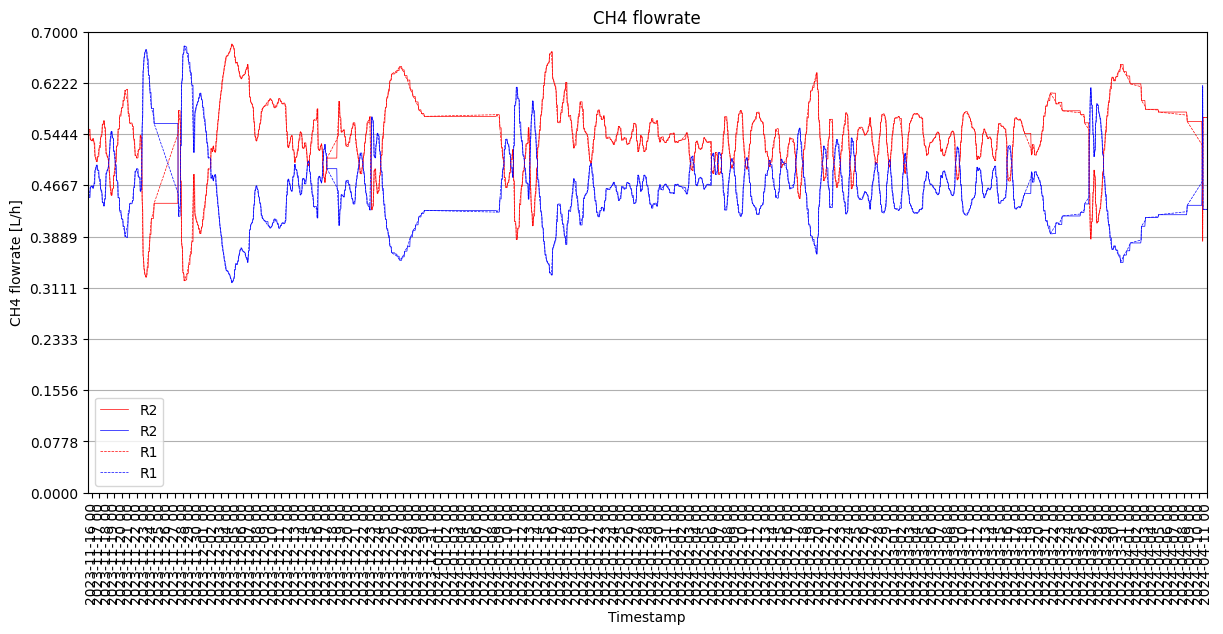

In [19]:
# LINE PLOT
# Plot the overall time series
reactor = '2'
plt.figure(figsize=(12, 6))
plt.plot(filtered_data_fir[f'{reactor}']['Timestamp'], filtered_data_fir[f'{reactor}']['xch4'], color='red', label='R2',linewidth=0.5)
plt.plot(filtered_data_fir[f'{reactor}']['Timestamp'], filtered_data_fir[f'{reactor}']['xco2'], color='blue', label='R2',linewidth=0.5)
#plt.plot(filtered_data[f'{reactor}']['Timestamp'], filtered_data[f'{reactor}']['xch4']+filtered_data[f'{reactor}']['xco2'], color='orange', label='R2',linewidth=0.5)
plt.plot(filtered_data_fir[f'{reactor}']['Timestamp'], filtered_data_fir[f'{reactor}']['xch4_interp'], color='red', label='R1',linewidth=0.5, linestyle='--')
plt.plot(filtered_data_fir[f'{reactor}']['Timestamp'], filtered_data_fir[f'{reactor}']['xco2_interp'], color='blue', label='R1',linewidth=0.5, linestyle='--')
#plt.plot(filtered_data_fir[f'{reactor}']['Timestamp'], filtered_data_fir[f'{reactor}']['xch4']+filtered_data_fir[f'{reactor}']['xco2'], color='black', label='R2',linewidth=0.5)

plt.xlabel('Timestamp')
plt.ylabel('CH4 flowrate [L/h]')
title = 'CH4 flowrate'
plt.title(title)
plt.legend()
plt.xticks(rotation=90)
plt.tight_layout()
ax = plt.gca()
#ax.set_xlim([xmin, xmax])
#ax.set_ylim([0, 5])

# Set x-axis formatting to display dates as 'YYYY-MM-DD'
date_format = mdates.DateFormatter('%Y-%m-%d')
ax.xaxis.set_major_formatter(date_format)

# Set the locator for the x-axis to show every day
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))

# Set x-axis limits with timestamps (from 10:30 AM to 12:30 PM)
start_time = datetime(2023, 11, 15, 12, 0)
end_time = datetime(2024, 4, 11, 0, 0)

plt.xlim(mdates.date2num(start_time), mdates.date2num(end_time))
ax = plt.gca()
#ax.set_ylim([42, 42.4])
#ax.set_xlim([15000,15015])

# Set x-axis formatting to display dates as 'YYYY-MM-DD'
date_format = mdates.DateFormatter('%Y-%m-%d %H')
ax.xaxis.set_major_formatter(date_format)

# Set the locator for the x-axis to show every day
ax.xaxis.set_major_locator(mdates.HourLocator(interval=24))

# Specify the number of ticks on the y-axis
num_ticks = 10  # Adjust this value as needed

# Calculate tick positions based on the number of ticks
min_value = 0
max_value = 0.7
ax.set_ylim([min_value, max_value])
y_ticks = [min_value + i * ((max_value - min_value) / (num_ticks - 1)) for i in range(num_ticks)]

# Set the ticks on the y-axis
plt.yticks(y_ticks)

plt.grid(axis='y')

# Specify the directory to save the figure
save_directory = 'C:/Users/lenovo/OneDrive - Politecnico di Milano/Work_cloud/DOTTORATO/Sperimentazione UIT/Software/'

# Save the plot to the specified directory with a desired filename
#plt.savefig(save_directory + f'{title}_{current_date}.png')

plt.show()

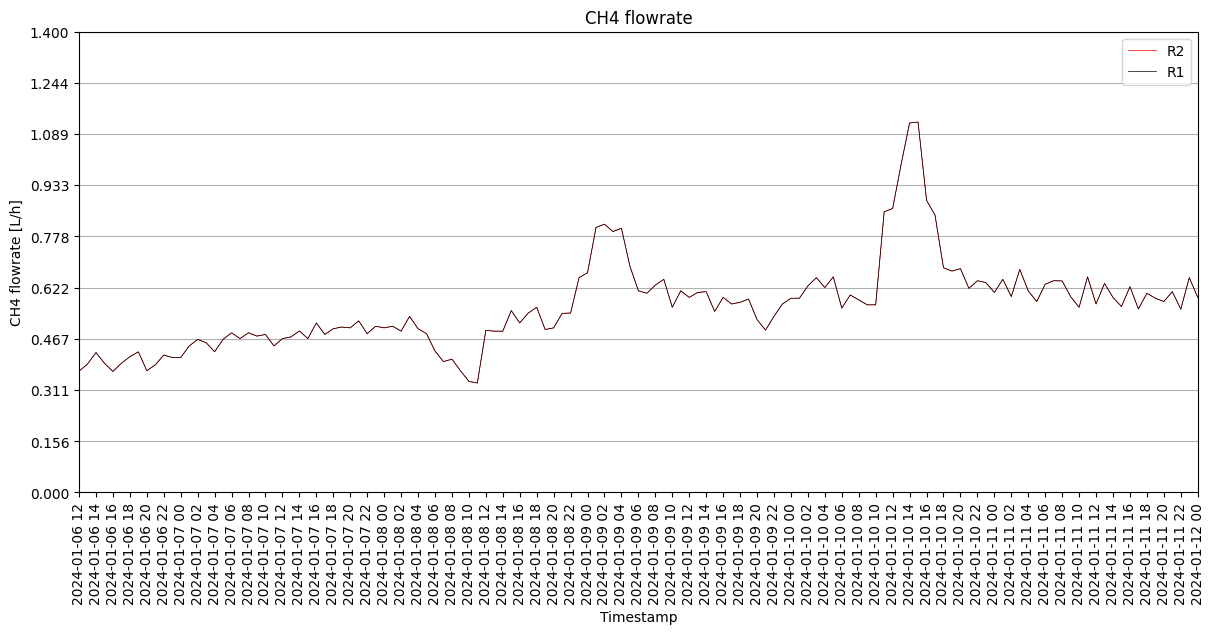

In [20]:
# LINE PLOT
# Plot the overall time series
reactor = '2'
plt.figure(figsize=(12, 6))
#plt.plot(filtered_data[f'{reactor}']['Timestamp'], filtered_data[f'{reactor}']['gas_rate_out'], color='blue', label='R2',linewidth=0.5)
plt.plot(filtered_data[f'{reactor}']['Timestamp'], filtered_data[f'{reactor}']['gas_rate'], color='red', label='R2',linewidth=0.5)
plt.plot(filtered_data_fir[f'{reactor}']['Timestamp'], filtered_data_fir[f'{reactor}']['gas_rate'], color='black', label='R1',linewidth=0.5)

plt.xlabel('Timestamp')
plt.ylabel('CH4 flowrate [L/h]')
title = 'CH4 flowrate'
plt.title(title)
plt.legend()
plt.xticks(rotation=90)
plt.tight_layout()
ax = plt.gca()
#ax.set_xlim([xmin, xmax])
#ax.set_ylim([0, 5])

# Set x-axis formatting to display dates as 'YYYY-MM-DD'
date_format = mdates.DateFormatter('%Y-%m-%d')
ax.xaxis.set_major_formatter(date_format)

# Set the locator for the x-axis to show every day
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))

# Set x-axis limits with timestamps (from 10:30 AM to 12:30 PM)
start_time = datetime(2024, 1, 6, 12, 0)
end_time = datetime(2024, 1, 12, 0, 0)

plt.xlim(mdates.date2num(start_time), mdates.date2num(end_time))
ax = plt.gca()
#ax.set_ylim([42, 42.4])
#ax.set_xlim([15000,15015])

# Set x-axis formatting to display dates as 'YYYY-MM-DD'
date_format = mdates.DateFormatter('%Y-%m-%d %H')
ax.xaxis.set_major_formatter(date_format)

# Set the locator for the x-axis to show every day
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))

# Specify the number of ticks on the y-axis
num_ticks = 10  # Adjust this value as needed

# Calculate tick positions based on the number of ticks
min_value = 0
max_value = 1.4
ax.set_ylim([min_value, max_value])
y_ticks = [min_value + i * ((max_value - min_value) / (num_ticks - 1)) for i in range(num_ticks)]

# Set the ticks on the y-axis
plt.yticks(y_ticks)

plt.grid(axis='y')

# Specify the directory to save the figure
save_directory = 'C:/Users/lenovo/OneDrive - Politecnico di Milano/Work_cloud/DOTTORATO/Sperimentazione UIT/Software/'

# Save the plot to the specified directory with a desired filename
#plt.savefig(save_directory + f'{title}_{current_date}.png')

plt.show()

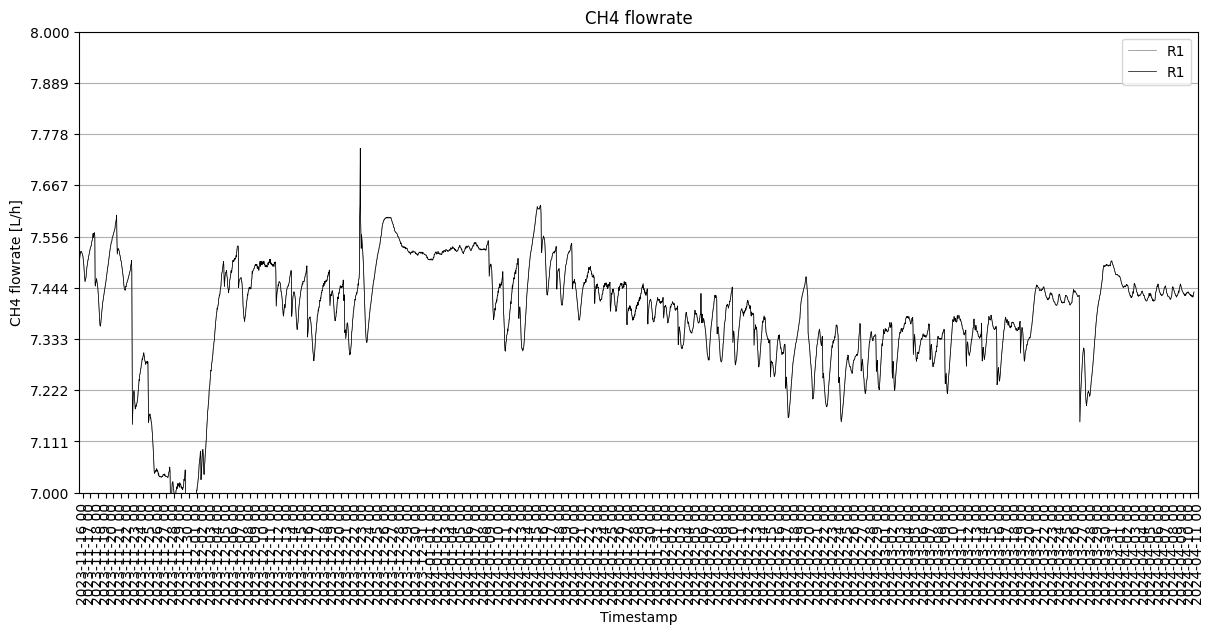

In [15]:
# LINE PLOT
# Plot the overall time series
plt.figure(figsize=(12, 6))
#plt.plot(filtered_data_fir[f'{reactor}']['Timestamp'], filtered_data_fir[f'{reactor}']['xco2'], color='black', label='R1',linewidth=0.5)
#plt.plot(filtered_data[f'{reactor}']['Timestamp'], filtered_data[f'{reactor}']['xch4']+filtered_data[f'{reactor}']['xco2'], color='orange', label='R2',linewidth=0.5)
#plt.plot(filtered_data_fir[f'{reactor}']['Timestamp'], filtered_data_fir[f'{reactor}']['xco2_interp'], color='black', label='R1',linewidth=0.5)
#plt.plot(filtered_data_fir[f'{reactor}']['Timestamp'], filtered_data_fir[f'{reactor}']['xch4']+filtered_data_fir[f'{reactor}']['xco2'], color='black', label='R2',linewidth=0.5)

plt.plot(filtered_data[f'{reactor}']['Timestamp'], filtered_data[f'{reactor}']['pHs'], color='grey', label='R1',linewidth=0.5)
plt.plot(filtered_data_fir[f'{reactor}']['Timestamp'], filtered_data_fir[f'{reactor}']['pHs'], color='black', label='R1',linewidth=0.5)

plt.xlabel('Timestamp')
plt.ylabel('CH4 flowrate [L/h]')
title = 'CH4 flowrate'
plt.title(title)
plt.legend()
plt.xticks(rotation=90)
plt.tight_layout()
ax = plt.gca()
#ax.set_xlim([xmin, xmax])
#ax.set_ylim([0, 5])

# Set x-axis formatting to display dates as 'YYYY-MM-DD'
date_format = mdates.DateFormatter('%Y-%m-%d')
ax.xaxis.set_major_formatter(date_format)

# Set the locator for the x-axis to show every day
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))

# Set x-axis limits with timestamps (from 10:30 AM to 12:30 PM)
start_time = datetime(2023, 11, 15, 12, 0)
end_time = datetime(2024, 4, 11, 0, 0)

plt.xlim(mdates.date2num(start_time), mdates.date2num(end_time))
ax = plt.gca()
#ax.set_ylim([42, 42.4])
#ax.set_xlim([15000,15015])

# Set x-axis formatting to display dates as 'YYYY-MM-DD'
date_format = mdates.DateFormatter('%Y-%m-%d %H')
ax.xaxis.set_major_formatter(date_format)

# Set the locator for the x-axis to show every day
ax.xaxis.set_major_locator(mdates.HourLocator(interval=24))

# Specify the number of ticks on the y-axis
num_ticks = 10  # Adjust this value as needed

# Calculate tick positions based on the number of ticks
min_value = 7
max_value = 8
ax.set_ylim([min_value, max_value])
y_ticks = [min_value + i * ((max_value - min_value) / (num_ticks - 1)) for i in range(num_ticks)]

# Set the ticks on the y-axis
plt.yticks(y_ticks)

plt.grid(axis='y')

# Specify the directory to save the figure
save_directory = 'C:/Users/lenovo/OneDrive - Politecnico di Milano/Work_cloud/DOTTORATO/Sperimentazione UIT/Software/'

# Save the plot to the specified directory with a desired filename
#plt.savefig(save_directory + f'{title}_{current_date}.png')

plt.show()

In [ ]:
# SAVE

In [21]:
# Save grouped data
# Get the current date
current_date = datetime.now().date()
# Format the date as a string
formatted_date = current_date.strftime('%d.%m.%Y')

directory = 'C:/Users/lenovo/OneDrive - Politecnico di Milano/Work_cloud/DOTTORATO/Modelling/Pilot_plant/UIT controller/'
excel_file_path = directory + f'UIT_analysis_{formatted_date}_cleaned.xlsx'

# Save grouped data to excel
#lists_dict = {'Qgas':groupby,'Qch4':groupby_Qch4,'ratio':groupby_ratio,'pH':groupby_pH,'tomato':groupby_tomato,'temperature':groupby_T}
with pd.ExcelWriter(excel_file_path, engine='openpyxl') as writer:
    for sheet_name, df in filtered_data_fir.items():
        df.to_excel(writer, sheet_name=sheet_name, index=False)

# Quantities that must be preserved are gas_rate, pHs, xco2_interp, xch4_interp